# 16 - Daughter grid convergence at large f̃ (even grid)

Notebook 15 found that the strategy-5 grid at its default 50 bins/decade, then even in ln a_q, is not
converged once the daughter is a large share of the dark matter. This asks (1) whether that matters
for the data, on a (mass, f̃) grid against a 400/decade reference, and (2) what limits convergence.

**Result.**
- **Where the nodes are.** Of the default 71 nodes only 17 fall inside the central 98% of births
  (a = 0.091–0.194) and 8 inside the central 80%; 37 come after the births are over (section 0).
- **Convergence is clean second order** (σ8_cb order 1.5–2.1 everywhere), and 400/decade is good to
  Δχ² ≤ 0.01 (against 800). The error is smooth: low-ℓ TT (ISW), a P_cb offset, and for warm daughters
  high-ℓ TT too.
- **Size.** It grows with f̃ and is largest for warm daughters. At 50/decade it exceeds Δχ² = 0.1 from
  f̃ = 0.1 at 10¹¹ GeV, from f̃ = 0.5 at 10¹² GeV, and near f̃ = 0.9 at 10¹⁴–10¹⁸ GeV; wherever accDM is
  detectable it stays below 6% of the accDM signal. The current chains stay at f̃ ≤ 0.006–0.23 (95%,
  10¹¹–10^15.7 GeV), where even this grid's error is ≲ 10⁻³ (and they use the born-fraction grid).
- **Cause.** Not the integrator (tolerance changes nothing) and not the background (Ω_acc right to
  2·10⁻⁷); moving a_min helps by ~35%; smooth births converge only at first order and are worse. The
  error is the resolution of the birth window by ~17 nodes. Fix: place nodes by born fraction
  (notebook 17; the default since 2026-10-05).
- **A second error at warm masses:** `l_max_ncdm = 17` is too short for a warm daughter at large f̃
  (−0.6% in σ8_cb at 10¹² GeV, f̃ = 0.5, at any grid); see notebook 19.
- A few comparisons show a Δχ² ≈ 0.04 jump that does not depend on the bin count, also seen in
  notebooks 12, 17 and 18.

Settings: the `connect/new` chains with their 10¹⁴ GeV best fit of 2026-10-05 and fixed ω_dm,tot
(fixed values, see `accdm_nb`), no sink, even grid. Δχ²: `accdm_nb.compare`, tolerance 0.1. Cached in
`16_cache.pkl` (~2 h from scratch). Chain markers: the current chains in `k12.1a0.133`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import (ELL, KK, CONNECT_NEW, LCDM_NEW14_OCT05, OMEGA_DM_TOT_OCT05, RunCache, a_min,
                      born_fraction, chains_dir, chi2_parts, compare, load_chain, mass_dirs, ok, q_size, show,
                      wquantile, plot_style)

plot_style()

SETTINGS = {**CONNECT_NEW, **LCDM_NEW14_OCT05, 'omega_dm_tot': OMEGA_DM_TOT_OCT05}
BINS, REF, F_NULL, DCHI2_TOL = [50, 100, 200, 400], 400, 1e-6, 0.1
MASSES, F_GRID = [11, 12, 14, 16, 18], [0.01, 0.1, 0.5, 0.9]


def params(log10m, f_tilde, **extra):
    return {**SETTINGS, 'm_acc_in_GeV': 10.0**log10m, 'f_tilde': f_tilde, **extra}


def per_decade(n):
    return {'accdm_q_bins_per_decade': n}


F95 = {float(d.name): wquantile(s['f_tilde'], s['weight'], 0.95)
       for d in mass_dirs(chains_dir('k12.1a0.133')) for s in [load_chain(d)]}
print('current chains, 95% f̃:', ', '.join('{:g}: {:.3f}'.format(m, f) for m, f in F95.items()))

current chains, 95% f̃: 11: 0.006, 12: 0.012, 13: 0.017, 14: 0.026, 15: 0.072, 15.301: 0.110, 15.699: 0.225


## 0. Where the nodes are

In [2]:
AMIN = a_min()
rows = []
for n in BINS + [800]:
    F = born_fraction(np.exp(np.linspace(np.log(AMIN), 0, q_size(n, AMIN))))
    rows.append({'bins/decade': n, 'q_size': len(F), 'nodes in 1–99% of births': int(np.sum((F > 0.01) & (F < 0.99))),
                 'in 10–90%': int(np.sum((F > 0.1) & (F < 0.9))), 'after 99%': int(np.sum(F >= 0.99))})
print('a_min = {:.4f}'.format(AMIN))
show(pd.DataFrame(rows).set_index('bins/decade'), default='{:d}')

a_min = 0.0425


,q_size,nodes in 1–99% of births,in 10–90%,after 99%
bins/decade,,,,
50,71,17,8,37
100,139,33,16,72
200,277,66,32,144
400,551,132,63,286
800,1099,264,126,570


## 1. Does it matter for the data?

Δχ² of each density against 400/decade, the accDM signal (400/decade against f̃ = 10⁻⁶), and the
convergence order from σ8_cb at 50, 100, 200: p = log₂(|σ₅₀ − σ₁₀₀|/|σ₁₀₀ − σ₂₀₀|).

In [3]:
cache = RunCache('16_cache.pkl')
null = cache(params(14, F_NULL))
keys = [(lm, ft, n) for lm in MASSES for ft in F_GRID for n in BINS] + [(12, 0.9, 800), (16, 0.9, 800)]
res = dict(zip(keys, cache.many([params(lm, ft, **per_decade(n)) for lm, ft, n in keys])))
assert all(ok(r) for r in res.values())


def order(s50, s100, s200):
    return np.log2(abs(s50 - s100)/abs(s100 - s200))


rows = []
for lm in MASSES:
    for ft in F_GRID:
        ref = res[(lm, ft, REF)]
        row = {'log10 m': lm, 'f̃': ft, 'signal': chi2_parts(ref, null)['total']}
        row.update({'Δχ² {}'.format(n): compare(res[(lm, ft, n)], ref)['total'] for n in BINS[:-1]})
        c50 = compare(res[(lm, ft, 50)], ref)
        row.update({'50: lens': c50['lens'], '50: max ΔP_cb': c50['dpk'], '50: Δσ8_cb': c50['dsigma8'],
                    'order': order(*(res[(lm, ft, n)]['sigma8_cb'] for n in BINS[:-1]))})
        rows.append(row)
table = pd.DataFrame(rows).set_index(['log10 m', 'f̃'])
show(table, {'order': '{:.1f}', '50: Δσ8_cb': '{:+.1e}'}, default='{:.1e}')
for lm, ft in [(12, 0.9), (16, 0.9)]:
    print('reference error at log10 m = {}, f̃ = {}: Δχ²(400 vs 800) = {:.1e}'.format(
        lm, ft, compare(res[(lm, ft, REF)], res[(lm, ft, 800)])['total']))

signal   Δχ² 50  Δχ² 100  Δχ² 200 50: lens 50: max ΔP_cb  \
log10 m f̃                                                                
11      0.01  7.5e+00  9.0e-04  3.2e-04  2.8e-05  5.1e-06       3.6e-05   
        0.10  7.6e+02  1.4e+01  1.5e+00  1.1e-01  2.3e-03       1.6e-03   
        0.50  4.1e+04  2.3e+03  6.0e+02  1.5e+01  1.2e-01       3.4e-02   
        0.90  2.4e+05  1.0e+04  2.1e+03  5.2e+01  4.3e-02       1.2e-01   
12      0.01  8.1e-01  8.1e-06  1.5e-06  5.4e-07  1.2e-06       3.4e-05   
        0.10  7.2e+01  6.8e-02  2.0e-03  4.2e-02  4.1e-04       5.3e-04   
        0.50  1.7e+03  3.7e+01  1.3e+00  6.9e-02  5.3e-02       1.2e-02   
        0.90  8.3e+03  2.1e+02  7.9e+00  1.9e-01  2.4e-01       4.4e-02   
14      0.01  3.2e-01  1.6e-06  1.1e-06  4.2e-07  9.3e-07       1.0e-05   
        0.10  2.8e+01  2.6e-04  1.5e-04  4.6e-05  2.2e-04       3.7e-04   
        0.50  4.2e+02  5.8e-02  2.4e-03  7.1e-04  4.6e-03       1.0e-02   
        0.90  7.9e+02  2.2e-01  4.0e-02  7.0e-02  3.1e-02       3.8e-02   
16      0.01  2.5e-03  1.1e-06  1.2e-06  4.7e-07  5.4e-07       7.2e-06   
        0.10  2.4e-01  2.4e-05  4.1e-02  5.0e-05  1.3e-05       3.7e-04   
        0.50  5.2e+00  6.0e-02  2.1e-03  5.4e-05  1.0e-02       1.0e-02   
        0.90  1.4e+01  1.9e-01  7.2e-02  1.6e-02  4.7e-02       3.6e-02   
18      0.01  7.9e-07  1.1e-06  4.1e-02  4.4e-07  5.1e-07       7.2e-06   
        0.10  8.0e-05  1.6e-05  1.8e-04  5.0e-05  5.4e-06       1.3e-04   
        0.50  1.2e-03  6.4e-02  4.3e-02  5.7e-05  1.4e-02       3.2e-03   
        0.90  4.6e-02  2.5e-01  1.1e-01  5.7e-02  6.3e-02       1.0e-02   

             50: Δσ8_cb order  
log10 m f̃                     
11      0.01   -8.4e-06   1.7  
        0.10   -7.1e-04   2.0  
        0.50   -1.7e-02   1.9  
        0.90   -6.0e-02   1.7  
12      0.01   -2.8e-06   1.5  
        0.10   -2.2e-04   2.0  
        0.50   -6.1e-03   2.1  
        0.90   -2.2e-02   2.1  
14      0.01   -2.2e-06   1.4  
        0.10   -1.8e-04   2.0  
        0.50   -4.9e-03   2.1  
        0.90   -1.8e-02   2.1  
16      0.01   -8.8e-07   1.6  
        0.10   -7.9e-05   2.0  
        0.50   -2.0e-03   2.1  
        0.90   -6.4e-03   2.1  
18      0.01   -5.3e-07   1.5  
        0.10   -4.9e-05   2.0  
        0.50   -1.2e-03   2.1  
        0.90   -4.2e-03   2.1

reference error at log10 m = 12, f̃ = 0.9: Δχ²(400 vs 800) = 1.0e-02
reference error at log10 m = 16, f̃ = 0.9: Δχ²(400 vs 800) = 2.2e-03


### 1b. Against the chains

Δχ²(50/decade vs 400) along f̃ per mass, with the current chains' 95% f̃ (stars, interpolated on the grid).

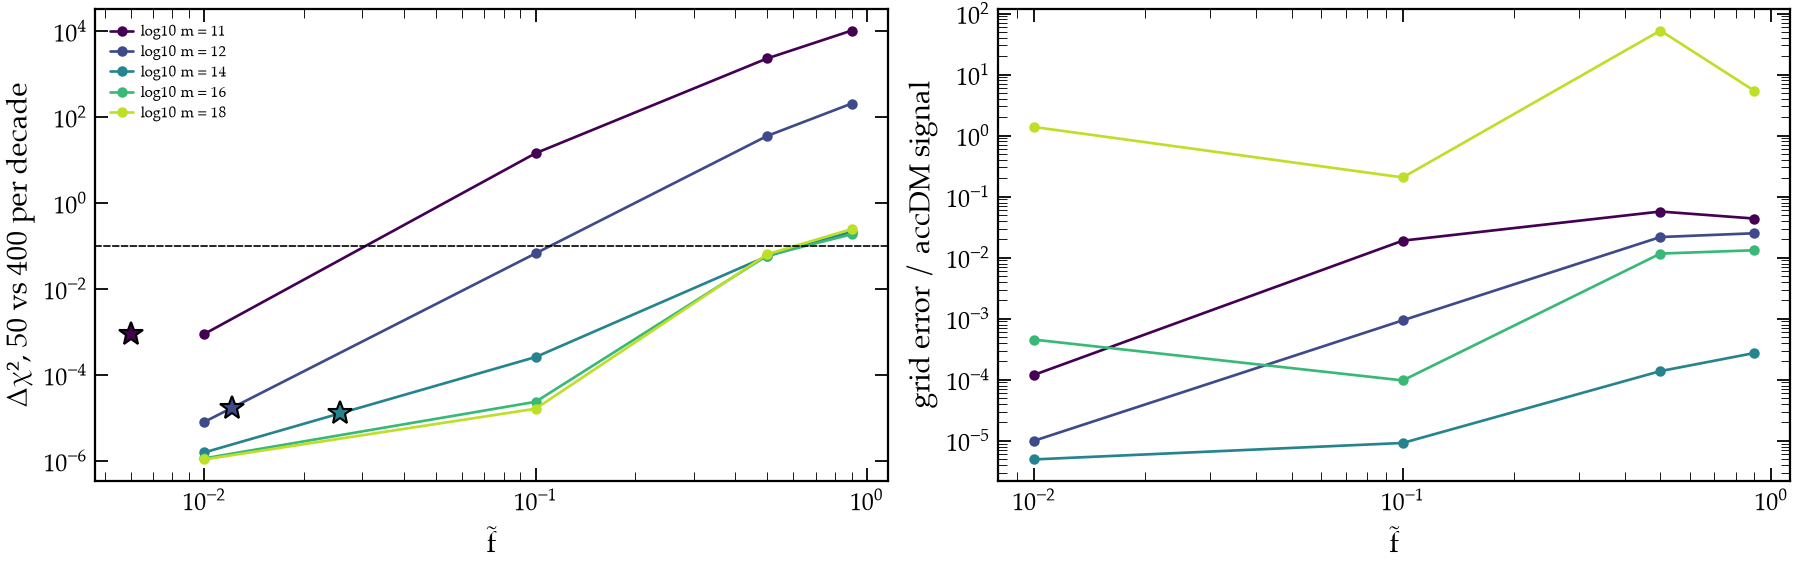

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for c, lm in zip(plt.cm.viridis(np.linspace(0, 0.9, len(MASSES))), MASSES):
    d50 = np.array([table.loc[(lm, ft), 'Δχ² 50'] for ft in F_GRID])
    sig = np.array([table.loc[(lm, ft), 'signal'] for ft in F_GRID])
    axes[0].loglog(F_GRID, d50, 'o-', color=c, ms=4, label='log10 m = {:g}'.format(lm))
    axes[1].loglog(F_GRID, d50/sig, 'o-', color=c, ms=4)
    if lm in F95:
        axes[0].plot(F95[lm], np.exp(np.interp(np.log(F95[lm]), np.log(F_GRID), np.log(d50))), '*', color=c, ms=12, mec='k')
axes[0].axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
axes[0].set_ylabel('Δχ², 50 vs 400 per decade')
axes[1].set_ylabel('grid error / accDM signal')
for ax in axes:
    ax.set_xlabel('f̃')
axes[0].legend(fontsize=7)
plt.show()

## 2. What limits convergence?

At a warm (10¹² GeV, f̃ = 0.5) and a cold point (10¹⁶ GeV, f̃ = 0.9): the sequence with smooth births
(each bin born gradually across its cell), and 50/decade with one change each: integrator tolerance
10⁻⁵ → 10⁻⁷, a_min cut `accdm_q_number_tol` 10⁻⁶ → 10⁻⁹, daughter hierarchy `l_max_ncdm` 17 → 50. All
against plain 400/decade. Then 400/decade with `l_max_ncdm = 50` separates the hierarchy error of the
reference itself.

In [5]:
POINTS = [(12, 0.5), (16, 0.9)]
VARIANTS = {'tol_pert 1e-7': {'tol_perturbations_integration': 1e-7}, 'q_tol 1e-9': {'accdm_q_number_tol': 1e-9},
            'l_max_ncdm 50': {'l_max_ncdm': 50}}
mech = {}
for lm, ft in POINTS:
    for n in BINS:
        mech[(lm, ft, 'smooth', n)] = cache(params(lm, ft, accdm_smooth_births=1, **per_decade(n)))
    for label, extra in VARIANTS.items():
        mech[(lm, ft, label, 50)] = cache(params(lm, ft, **per_decade(50), **extra))
    mech[(lm, ft, 'l_max_ncdm 50', REF)] = cache(params(lm, ft, l_max_ncdm=50, **per_decade(REF)))

rows = []
for lm, ft in POINTS:
    ref, long_ref = res[(lm, ft, REF)], mech[(lm, ft, 'l_max_ncdm 50', REF)]
    cases = [('plain', n, res[(lm, ft, n)]) for n in BINS[:-1]] + \
            [('smooth', n, mech[(lm, ft, 'smooth', n)]) for n in BINS] + \
            [(label, 50, mech[(lm, ft, label, 50)]) for label in VARIANTS]
    for label, n, out in cases:
        c = compare(out, ref)
        rows.append({'point': '{:g}, {:g}'.format(lm, ft), 'setting': '{} {}/dec'.format(label, n), 'Δχ²': c['total'],
                     'lens': c['lens'], 'max ΔP_cb': c['dpk'], 'Δσ8_cb': c['dsigma8'], 'ΔΩ_acc': c['domega']})
    for label, a in (('400, l_max 17 vs 400, l_max 50', ref), ('50, l_max 50 vs 400, l_max 50', mech[(lm, ft, 'l_max_ncdm 50', 50)])):
        c = compare(a, long_ref)
        rows.append({'point': '{:g}, {:g}'.format(lm, ft), 'setting': label, 'Δχ²': c['total'], 'lens': c['lens'],
                     'max ΔP_cb': c['dpk'], 'Δσ8_cb': c['dsigma8']})
show(pd.DataFrame(rows).set_index(['point', 'setting']), {'Δσ8_cb': '{:+.1e}', 'ΔΩ_acc': '{:+.1e}'}, default='{:.1e}')

Δχ²     lens max ΔP_cb    Δσ8_cb  \
point   setting                                                                
12, 0.5 plain 50/dec                    3.7e+01  5.3e-02   1.2e-02  -6.1e-03   
        plain 100/dec                   1.3e+00  5.6e-03   3.4e-03  -1.6e-03   
        plain 200/dec                   6.9e-02  9.5e-03   1.2e-03  -5.4e-04   
        smooth 50/dec                   3.2e+01  8.1e-01   2.3e-02  +1.0e-02   
        smooth 100/dec                  3.7e+00  2.1e-01   1.2e-02  +5.6e-03   
        smooth 200/dec                  2.7e-01  5.5e-02   7.0e-03  +3.2e-03   
        smooth 400/dec                  8.7e-02  1.5e-02   4.3e-03  +1.9e-03   
        tol_pert 1e-7 50/dec            3.7e+01  5.3e-02   1.2e-02  -6.1e-03   
        q_tol 1e-9 50/dec               2.3e+01  2.2e-02   8.4e-03  -4.1e-03   
        l_max_ncdm 50 50/dec            1.4e+01  4.2e-02   1.2e-02  +3.5e-05   
        400, l_max 17 vs 400, l_max 50  2.0e-01  1.9e-01   1.6e-02  -6.1e-03   
        50, l_max 50 vs 400, l_max 50   1.4e+01  5.3e-02   1.2e-02  -6.1e-03   
16, 0.9 plain 50/dec                    1.9e-01  4.7e-02   3.6e-02  -6.4e-03   
        plain 100/dec                   7.2e-02  1.9e-02   9.4e-03  -1.6e-03   
        plain 200/dec                   1.6e-02  4.5e-03   3.2e-03  -5.5e-04   
        smooth 50/dec                   9.1e-02  3.2e-02   4.5e-02  +5.6e-03   
        smooth 100/dec                  2.7e-02  8.8e-03   2.4e-02  +3.2e-03   
        smooth 200/dec                  9.6e-03  2.4e-03   1.4e-02  +1.9e-03   
        smooth 400/dec                  4.6e-03  7.2e-04   8.4e-03  +1.3e-03   
        tol_pert 1e-7 50/dec            1.9e-01  4.7e-02   3.6e-02  -6.4e-03   
        q_tol 1e-9 50/dec               1.2e-01  3.0e-02   2.4e-02  -4.1e-03   
        l_max_ncdm 50 50/dec            1.9e-01  4.7e-02   3.6e-02  -6.3e-03   
        400, l_max 17 vs 400, l_max 50  9.0e-04  1.1e-06   9.2e-04  -5.9e-05   
        50, l_max 50 vs 400, l_max 50   1.9e-01  4.7e-02   3.6e-02  -6.4e-03   

                                          ΔΩ_acc  
point   setting                                   
12, 0.5 plain 50/dec                    +2.0e-07  
        plain 100/dec                   -3.2e-11  
        plain 200/dec                   -1.9e-12  
        smooth 50/dec                   +2.0e-07  
        smooth 100/dec                  -3.2e-11  
        smooth 200/dec                  -1.9e-12  
        smooth 400/dec                  +0.0e+00  
        tol_pert 1e-7 50/dec            +2.0e-07  
        q_tol 1e-9 50/dec               +8.2e-07  
        l_max_ncdm 50 50/dec            +2.0e-07  
        400, l_max 17 vs 400, l_max 50         -  
        50, l_max 50 vs 400, l_max 50          -  
16, 0.9 plain 50/dec                    +2.0e-07  
        plain 100/dec                   -3.2e-11  
        plain 200/dec                   -1.9e-12  
        smooth 50/dec                   +2.0e-07  
        smooth 100/dec                  -3.2e-11  
        smooth 200/dec                  -1.9e-12  
        smooth 400/dec                  +0.0e+00  
        tol_pert 1e-7 50/dec            +2.0e-07  
        q_tol 1e-9 50/dec               +8.2e-07  
        l_max_ncdm 50 50/dec            +2.0e-07  
        400, l_max 17 vs 400, l_max 50         -  
        50, l_max 50 vs 400, l_max 50          -

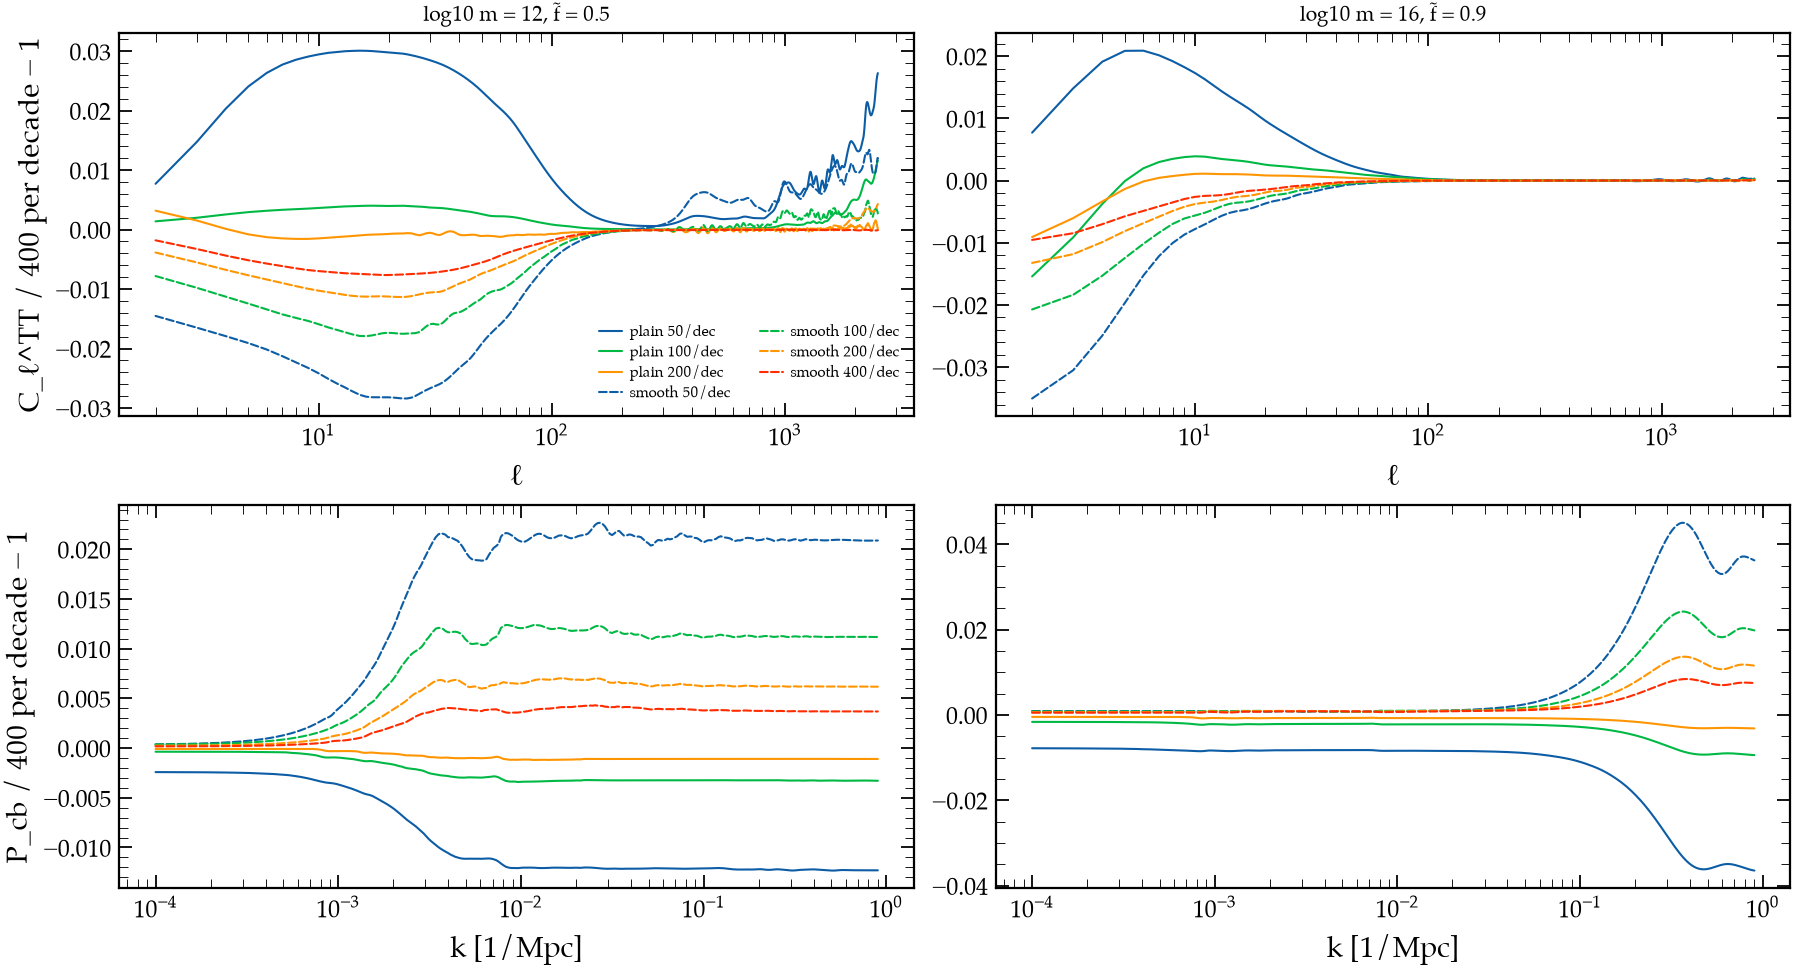

In [6]:
fig, axes = plt.subplots(2, len(POINTS), figsize=(12, 6.5), constrained_layout=True)
for j, (lm, ft) in enumerate(POINTS):
    ref = res[(lm, ft, REF)]
    for label, ls in (('plain', '-'), ('smooth', '--')):
        for c, n in zip(('C0', 'C1', 'C2', 'C3'), BINS):
            out = res[(lm, ft, n)] if label == 'plain' else mech[(lm, ft, 'smooth', n)]
            if label == 'plain' and n == REF:
                continue
            axes[0, j].semilogx(ELL, out['tt']/ref['tt'] - 1, color=c, ls=ls, lw=1, label='{} {}/dec'.format(label, n))
            axes[1, j].semilogx(KK, out['pk_cb']/ref['pk_cb'] - 1, color=c, ls=ls, lw=1)
    axes[0, j].set_title('log10 m = {:g}, f̃ = {:g}'.format(lm, ft), fontsize=10)
    axes[1, j].set_xlabel('k [1/Mpc]')
    axes[0, j].set_xlabel('ℓ')
axes[0, 0].set_ylabel('C_ℓ^TT / 400 per decade − 1')
axes[1, 0].set_ylabel('P_cb / 400 per decade − 1')
axes[0, 0].legend(fontsize=7, ncol=2)
plt.show()